### Data Visualization

1. now we will do geospation analyis based on the neigbourhood data
2. join with our citibike data,
3. visualize top routes
4. change width
5. change color
6. Coropleth Maps

In [2]:
import os
import sys
from pathlib import Path

env_path = Path(sys.prefix)

os.environ["PROJ_LIB"] = str(env_path / "Library" / "share" / "proj")
os.environ["GDAL_DATA"] = str(env_path / "Library" / "share" / "gdal")

print(os.environ["PROJ_LIB"])
print(os.environ["GDAL_DATA"])

c:\Users\Tatev\miniconda3new\envs\citibike-env\Library\share\proj
c:\Users\Tatev\miniconda3new\envs\citibike-env\Library\share\gdal


In [3]:
import geopandas as gpd

import requests

import numpy as np
import pandas as pd
import plotly.express as px
import folium
import shutil
import glob
import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile

In [4]:
citibike_df = pd.read_csv("../data/JC/JC2025_Enriched.csv")

citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,month,month_name,day_of_week,hour,season,ride_duration_minutes
0,04CF7A399050E404,classic_bike,2025-02-22 17:40:16.500,2025-02-22 17:47:22.479,Jersey & 3rd,JC074,Van Vorst Park,JC035,40.723332,-74.045953,40.718489,-74.047727,casual,2025-02-22,2025-02,February,Saturday,17,Winter,7.09965
1,124AC7493E82D845,classic_bike,2025-02-21 12:28:13.319,2025-02-21 12:35:44.762,Jersey & 3rd,JC074,Columbus Drive,JC014,40.723332,-74.045953,40.718355,-74.038914,member,2025-02-21,2025-02,February,Friday,12,Winter,7.52405
2,1A3BCA838E968327,classic_bike,2025-02-01 14:17:43.272,2025-02-01 14:59:09.894,Jersey & 3rd,JC074,Grove St PATH,JC115,40.723332,-74.045953,40.719410,-74.043090,casual,2025-02-01,2025-02,February,Saturday,14,Winter,41.44370
3,5994017EE989D6EE,electric_bike,2025-02-22 11:36:29.292,2025-02-22 11:49:51.531,Jersey & 3rd,JC074,Jersey & 3rd,JC074,40.723332,-74.045953,40.723332,-74.045953,casual,2025-02-22,2025-02,February,Saturday,11,Winter,13.37065
4,F81BCB97915C6BE6,electric_bike,2025-02-28 22:56:26.546,2025-02-28 23:07:40.391,Jersey & 3rd,JC074,Monroe St & 11 St,HB508,40.723332,-74.045953,40.750109,-74.036637,casual,2025-02-28,2025-02,February,Friday,22,Winter,11.23075


In [5]:

citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 948635 entries, 0 to 948634
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ride_id                948635 non-null  str    
 1   rideable_type          948635 non-null  str    
 2   started_at             948635 non-null  str    
 3   ended_at               948635 non-null  str    
 4   start_station_name     948634 non-null  str    
 5   start_station_id       948634 non-null  str    
 6   end_station_name       947936 non-null  str    
 7   end_station_id         947804 non-null  str    
 8   start_lat              948635 non-null  float64
 9   start_lng              948635 non-null  float64
 10  end_lat                948635 non-null  float64
 11  end_lng                948635 non-null  float64
 12  member_casual          948635 non-null  str    
 13  date                   948635 non-null  str    
 14  month                  948635 non-null  str    

In [6]:
geojson_url = "https://data.jerseycitynj.gov/api/explore/v2.1/catalog/datasets/jersey-city-neighborhoods/exports/geojson"

geojson_path = "../data/JC/jersey-city-neighborhoods.geojson"

urlretrieve(geojson_url, geojson_path)

print("Downloaded")

Downloaded


In [8]:
import geopandas as gpd
from urllib.parse import urlencode
from pathlib import Path


url = '../data/JC/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,geo_point_2d,cartodb_id,area_sq_ft,acres,area,neighborho,color,geometry
0,"{'lon': -74.034926976, 'lat': 40.7292547932}",12,411601381.8,9449.068,Downtown,Newport,22.0,"POLYGON ((-74.03709 40.73404, -74.03062 40.733..."
1,"{'lon': -74.0623580331, 'lat': 40.6991894289}",52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,"{'lon': -74.0745396393, 'lat': 40.6942023599}",38,411601381.8,9449.068,Greenville,Port Liberte,NaN,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
3,"{'lon': -74.0612789066, 'lat': 40.7126760382}",35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,"{'lon': -74.0855031402, 'lat': 40.7007912121}",51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [9]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   geo_point_2d  53 non-null     object  
 1   cartodb_id    53 non-null     int32   
 2   area_sq_ft    53 non-null     float64 
 3   acres         53 non-null     float64 
 4   area          53 non-null     str     
 5   neighborho    53 non-null     str     
 6   color         18 non-null     float64 
 7   geometry      53 non-null     geometry
dtypes: float64(3), geometry(1), int32(1), object(1), str(2)
memory usage: 3.2+ KB


In [10]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
jersey_city = jersey_city.to_crs("EPSG:4326")

Matplotlib is building the font cache; this may take a moment.


<Axes: >

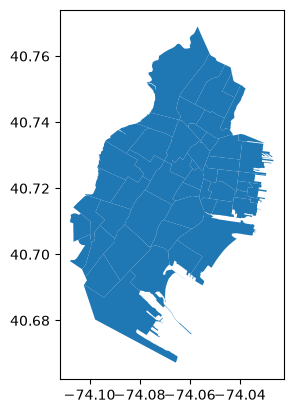

In [12]:
jersey_city.plot()

#### station_departures

In [13]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

In [14]:
start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

##### station_arrivals

In [15]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,04CF7A399050E404,JC035,Van Vorst Park,40.718489,-74.047727,arrival
1,124AC7493E82D845,JC014,Columbus Drive,40.718355,-74.038914,arrival
2,1A3BCA838E968327,JC115,Grove St PATH,40.719410,-74.043090,arrival
3,5994017EE989D6EE,JC074,Jersey & 3rd,40.723332,-74.045953,arrival
4,F81BCB97915C6BE6,HB508,Monroe St & 11 St,40.750109,-74.036637,arrival


##### Concatenate Departures and Arrivals

In [16]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)

station_activity_long = station_activity_long.dropna(
    subset=[
        "station_id",
        "station_name",
        "lat",
        "lng"
    ]
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,04CF7A399050E404,JC074,Jersey & 3rd,40.723332,-74.045953,departure
1,124AC7493E82D845,JC074,Jersey & 3rd,40.723332,-74.045953,departure
2,1A3BCA838E968327,JC074,Jersey & 3rd,40.723332,-74.045953,departure
3,5994017EE989D6EE,JC074,Jersey & 3rd,40.723332,-74.045953,departure
4,F81BCB97915C6BE6,JC074,Jersey & 3rd,40.723332,-74.045953,departure


##### Cleaning and Aggregating

In [17]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,arrival,1
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,arrival,1
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,arrival,1
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,arrival,1
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,arrival,1


##### Pivot the Data

In [18]:
station_summary = (
    station_activity_agg
    .pivot_table(
        index=[
            "station_id",
            "station_name",
            "lat",
            "lng"
        ],
        columns="activity_type",
        values="number_of_rides",
        fill_value=0
    )
    .reset_index()
)

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0


##### Rename and Create Final Metrics

In [19]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,44918.0,42388.0,87306.0,-2530.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,25504.0,24723.0,50227.0,-781.0
2,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0
3,JC009,Hamilton Park,40.727596,-74.044247,21224.0,21139.0,42363.0,-85.0
4,JC066,Newport PATH,40.727224,-74.033759,19590.0,19554.0,39144.0,-36.0


In [21]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,44918.0,42388.0,87306.0,-2530.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,25504.0,24723.0,50227.0,-781.0,POINT (-74.0303 40.73594)
2,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0,POINT (-74.02901 40.73672)
3,JC009,Hamilton Park,40.727596,-74.044247,21224.0,21139.0,42363.0,-85.0,POINT (-74.04425 40.7276)
4,JC066,Newport PATH,40.727224,-74.033759,19590.0,19554.0,39144.0,-36.0,POINT (-74.03376 40.72722)


##### Create Route-Level Summary

In [22]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_name"] +
    " → " +
    route_summary["end_station_name"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
81,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4392,Hoboken Terminal - Hudson St & Hudson Pl → Hob...
5462,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4005,McGinley Square → Bergen Ave & Sip Ave
8526,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,3848,Grove St PATH → Marin Light Rail
3834,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3596,Marin Light Rail → Grove St PATH
8540,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3471,Grove St PATH → Liberty Light Rail


##### Inspect Top Routes

In [23]:
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
81,Hoboken Terminal - Hudson St & Hudson Pl → Hob...,4392
5462,McGinley Square → Bergen Ave & Sip Ave,4005
8526,Grove St PATH → Marin Light Rail,3848
3834,Marin Light Rail → Grove St PATH,3596
8540,Grove St PATH → Liberty Light Rail,3471
5275,Liberty Light Rail → Grove St PATH,3351
8265,Bergen Ave & Sip Ave → McGinley Square,3336
7978,Hoboken Ave at Monmouth St → Hoboken Terminal ...,3161
4458,Brunswick St → Grove St PATH,2964
3689,Hamilton Park → Grove St PATH,2776


##### Drawing Top Lines with Folium

In [24]:
import folium

top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

##### Check CRS Before Spatial Join

In [25]:
print("Station CRS:", station_gdf.crs)
print("Neighborhood CRS:", jersey_city.crs)

Station CRS: EPSG:4326
Neighborhood CRS: EPSG:4326


In [26]:
station_gdf = station_gdf.to_crs("EPSG:4326")
jersey_city = jersey_city.to_crs("EPSG:4326")

In [27]:
jersey_city.columns

Index(['geo_point_2d', 'cartodb_id', 'area_sq_ft', 'acres', 'area',
       'neighborho', 'color', 'geometry'],
      dtype='str')

##### Spatial Join: Assign Stations to Neighborhoods

In [28]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,geo_point_2d,cartodb_id,area_sq_ft,acres,area,neighborho,color
0,JC115,Grove St PATH,40.719410,-74.043090,44918.0,42388.0,87306.0,-2530.0,POINT (-74.04309 40.71941),49,"{'lon': -74.0472335875, 'lat': 40.718943275}",2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0
3,JC009,Hamilton Park,40.727596,-74.044247,21224.0,21139.0,42363.0,-85.0,POINT (-74.04425 40.7276),16,"{'lon': -74.0466720842, 'lat': 40.7274360019}",18,411601381.8,9449.068,Downtown,Hamilton Park,28.0
4,JC066,Newport PATH,40.727224,-74.033759,19590.0,19554.0,39144.0,-36.0,POINT (-74.03376 40.72722),0,"{'lon': -74.034926976, 'lat': 40.7292547932}",12,411601381.8,9449.068,Downtown,Newport,22.0
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,19068.0,19116.0,38184.0,48.0,POINT (-74.06444 40.73101),18,"{'lon': -74.0634658925, 'lat': 40.7337571064}",31,411601381.8,9449.068,Journal Square,Journal Square,NaN
6,JC116,Exchange Pl,40.716366,-74.034344,19102.0,19019.0,38121.0,-83.0,POINT (-74.03434 40.71637),48,"{'lon': -74.0335387302, 'lat': 40.7164581776}",13,411601381.8,9449.068,Downtown,Exchange Place,23.0


In [29]:
print("All stations:", len(station_gdf))
print("Stations inside Jersey City neighborhoods:", len(station_neighborhood))

All stations: 480
Stations inside Jersey City neighborhoods: 78


##### Neighborhood-Level Summary

In [34]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborho', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborho,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,91265.0,93692.0,184957.0,-2427.0,30826.166667
17,Palus Hook,6,56921.0,56529.0,113450.0,392.0,18908.333333
14,Newport,2,37414.0,37434.0,74848.0,-20.0,37424.000000
10,Journal Square,3,30998.0,30586.0,61584.0,412.0,20528.000000
4,Hamilton Park,2,30096.0,30245.0,60341.0,-149.0,30170.500000


##### Create Center Point for the Map

In [35]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.734090673586294), np.float64(-74.00151301587097))

##### Visualize Each Station as a Point

In [36]:
station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

##### Merge Neighborhood Metrics Back to Polygons

In [38]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborho',
    how="left"
)

neighborhood_choropleth_gdf.head()

,geo_point_2d,cartodb_id,area_sq_ft,acres,area,neighborho,color,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,"{'lon': -74.034926976, 'lat': 40.7292547932}",12,411601381.8,9449.068,Downtown,Newport,22.0,"POLYGON ((-74.03709 40.73404, -74.03062 40.733...",2.0,37414.0,37434.0,74848.0,-20.0,37424.000000
1,"{'lon': -74.0623580331, 'lat': 40.6991894289}",52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,"{'lon': -74.0745396393, 'lat': 40.6942023599}",38,411601381.8,9449.068,Greenville,Port Liberte,NaN,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,3.0,21.000000
3,"{'lon': -74.0612789066, 'lat': 40.7126760382}",35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,29677.0,29559.0,59236.0,118.0,9872.666667
4,"{'lon': -74.0855031402, 'lat': 40.7007912121}",51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6022.0,5903.0,11925.0,119.0,745.312500


In [40]:
# We replace missing values with zero
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborho',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborho,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Newport,2.0,37414.0,37434.0,74848.0,37424.000000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.000000
2,Port Liberte,1.0,12.0,9.0,21.0,21.000000
3,Lafayette,6.0,29677.0,29559.0,59236.0,9872.666667
4,Jackson Hill,16.0,6022.0,5903.0,11925.0,745.312500


### Step 17: Choropleth Map

#### Helper Function for Folium Choropleth

In [41]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

#### Choropleth: Total Activity by Neighborhood

In [43]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total Citi Bike Activity",
    neighborhood_col="neighborho"
)

total_activity_map

##### Choropleth by Number of Stations

In [45]:
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborho"
)

station_count_map

##### Choropleth by Average Activity per Station

In [46]:
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborho"
)

avg_activity_map

##### Choropleth by Total Departures

In [48]:
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborho"
)

departures_map

##### Choropleth by Total Arrivals

In [49]:
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborho"
)

arrivals_map